Костин Арсений, 8Е21, вариант 3.

Для 1 лаб работы по CV необходимо реализовать базовый минимум операций над изображениями
Входное изображение в формате (RGB, не чёрно-белое)
1. Фильтры
<br>1.1 Медианный фильтр
<br>1.2 Фильтр гаусса
2. Морфологические операции
<br>2.1 Эрозия
<br>2.2 Дилатация
3. Прочие операции
<br>3.1 пороговая бинаризация (для rgb и grayscale изображения)
<br>3.2 выравнивание гистограммы
<br>3.3 поворот изображений на угол кратный 90 градусов


Использовать методы OpenCV для реализации операций нельзя. Допустимы только методы cv2.imread() и cv2.imshow(). Все методы должны быть реализованы вручную.

In [114]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [115]:
image1=cv2.imread('lab1/sample_image.jpg')
image2=cv2.imread('lab1/sample_image2.png')
image3=cv2.imread('lab1/sample_image3.png')

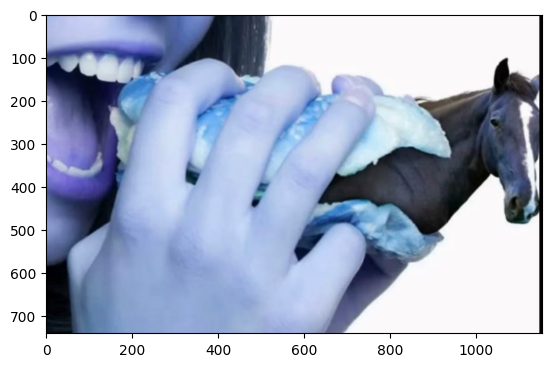

In [116]:
plt.imshow(image1)

In [117]:
image1_RGB = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

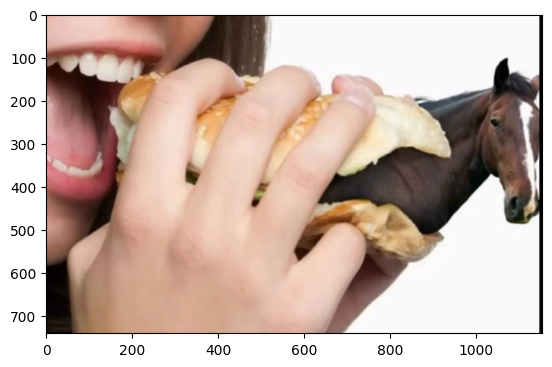

In [118]:
plt.imshow(image1_RGB)

In [119]:
print(image1_RGB)

[[[225 179 164]
  [225 179 164]
  [225 179 164]
  ...
  [  3   1   4]
  [  1   0   2]
  [  0   0   0]]

 [[225 179 164]
  [225 179 164]
  [226 180 165]
  ...
  [  3   1   4]
  [  1   0   2]
  [  0   0   0]]

 [[226 180 165]
  [226 180 165]
  [226 180 165]
  ...
  [  3   1   4]
  [  1   0   2]
  [  0   0   0]]

 ...

 [[ 15   7   5]
  [ 15   7   5]
  [ 14   6   4]
  ...
  [  4   2   5]
  [  1   0   2]
  [  0   0   0]]

 [[ 12   4   2]
  [ 12   4   2]
  [ 12   4   2]
  ...
  [  4   2   5]
  [  1   0   2]
  [  0   0   0]]

 [[ 12   4   2]
  [ 12   4   2]
  [ 12   4   2]
  ...
  [  4   2   5]
  [  1   0   2]
  [  0   0   0]]]


# 1. ФИЛЬТРЫ

### 1.1 Медианный фильтр

Медианный фильтр - один из методов борьбы с "шумами". Суть заключается в том, что создается "окно" для проверки. Внутри окна элементы упорядочиваются по возрастанию/убыванию. Как медианное значение берется число в середине этого окна. Если таких чисел несколько, то берется среднее значение двух чисел посередине окна. Если рассмотреть одномерный массив как объект, к котрому будет применен фильтр:
(Используя пример из википедии: https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D0%B4%D0%B8%D0%B0%D0%BD%D0%BD%D1%8B%D0%B9_%D1%84%D0%B8%D0%BB%D1%8C%D1%82%D1%80)
<p>
Пусть есть одномерный массив x = [2 80 6 3]
Пусть окно проверки будет размером 3, обозначено круглыми скобками

1 итерация: (2 80 6)
упорядочить
(2 6 80) = медианное значение 6 = выход итерации = 6

2 итерация: (80 6 3)
упорядочить
(3 6 80) = медианное значение 6 = выход итерации 6

Алогритм выполнен, выход фильтра [6 6], потеряны 2 элемента. Тренд сохраняется и при других размерах "окна". Таким образом: (длина окна - 1)/2 = количество потерянных элементов с одного края. То есть, в нашем случае были потеряны первый и последний элементы исходного массива. Продублируем элементы. Получаем:
[2 2 80 6 3 3]
Применим к исправленному исходному массиву медианный фильтр

1 итерация: (2 2 80)
упорядочить
(2 2 80) = медианное значение 2 = выход итерации = 2

2 итерация: (2 80 6)
упорядочить
(2 6 80) = медианное значение 6 = выход итерации = 6

3 итерация: (80 6 3)
упорядочить
(3 6 80) = медианное значение 6 = выход итерации = 6

4 итерация: (6 3 3)
упорядочить
(3 3 6) = медианное значение 3 = выход итерации = 3

Выход функции [2 6 6 3]. Значения были существенно сглажены.

Стоит упомянуть, что размер окна так же может быть четным. Но даже в одномерных массивах возникают определенные трудности по его применению. Например, можно брать левое медианное значение в окне, можно брать правое, существует путь с применением среднего арифметического обоих чисел и округленное для целого числа. Для проверки алгоритмических способностей фильтра в текущей задаче это будет избыточно. </p>


In [120]:
a = ["a","b", "c","d"]
print(a[1:3])

['b', 'c']


In [121]:
def median_1d(arr_initial, aperture):
    if aperture % 2 != 0:
        if aperture != 1:
            arr = [arr_initial[0]] + arr_initial + [arr_initial[-1]]
        else:
            arr = arr_initial
        curr_start = 0
        result = []
        for i in range(len(arr) - (aperture - 1)):
            curr_slice = arr[i : (aperture - 1 + i)+1]
            curr_slice = sorted(curr_slice)
            print(curr_slice)
            result.append(curr_slice[aperture // 2])
        return result
            
    else:
        print("Используйте окно нечетного размера")
        
print(median_1d([1,2,3,4,5], 3))

#random_arr = [6, 2, 4, 1, 2, 6, 9, 3, 1, 7] - 8 times for 3el window; 10 elements
#random_arr_ext = [6, 6, 2, 4, 1, 2, 6, 9, 3, 1, 7, 7] - 10 times for 3el window; 12 elements


# aperture 3 = ind 1
# aperture 5 = ind 2
# aperture 7 = ind 3

[1, 1, 2]
[1, 2, 3]
[2, 3, 4]
[3, 4, 5]
[4, 5, 5]
[1, 2, 3, 4, 5]


Проверим на примере из википедии

In [122]:
print(median_1d([2,80,6,3], 3))

[2, 2, 80]
[2, 6, 80]
[3, 6, 80]
[3, 3, 6]
[2, 6, 6, 3]


Результат совпал. Проверим при окне размером 1.

In [123]:
print(median_1d([2,80,6,3], 1))

[2]
[80]
[6]
[3]
[2, 80, 6, 3]


<p>
Смысла делать с окном ноль нет, не берется медианы.
<p>
Рассмотрим двумерный массив.
<p>
По сути алгоритм тот же, но в двумерном пространстве.
<p>
Берем окно квадратного размера, по сути матрицу меньшего порядка, чем изначальную. При этом рекомендация брать нечетную размерность аргументируется схожим образом как для одномерных массивов. Проходим этим окном по изображению. На каждой итерации разворачиваем текущий минор в ряд и применяем медианный фильтр. После этого заменяем центральный элемент минора на медианное значение от всех элеемнтов внутри этого минора - то есть, стоящее по середине отсортированного ряда.
<p>
Зададим матрицу:

In [124]:
sample_matrix = []
for i in range(100):
    temp_row = []
    for j in range(100):
        temp_row.append(random.randint(1,100))
    sample_matrix.append(temp_row)
for i in sample_matrix:
    print(i)

[58, 60, 68, 65, 19, 92, 41, 1, 25, 85, 88, 78, 97, 65, 11, 74, 43, 40, 79, 67, 48, 58, 12, 91, 38, 65, 85, 24, 85, 15, 43, 89, 12, 57, 95, 18, 93, 31, 52, 20, 74, 93, 98, 91, 65, 58, 88, 30, 58, 48, 92, 71, 83, 66, 6, 54, 25, 89, 91, 78, 24, 4, 2, 88, 84, 90, 46, 18, 13, 13, 87, 48, 63, 95, 77, 36, 27, 18, 36, 8, 71, 61, 51, 17, 95, 88, 100, 24, 73, 81, 74, 37, 58, 15, 61, 85, 4, 49, 79, 6]
[23, 12, 4, 66, 76, 51, 74, 57, 10, 43, 11, 55, 55, 53, 13, 78, 17, 77, 36, 14, 84, 69, 52, 83, 73, 9, 89, 67, 37, 83, 87, 80, 54, 38, 42, 58, 67, 63, 32, 7, 36, 55, 46, 2, 96, 89, 37, 50, 10, 17, 77, 79, 10, 95, 66, 4, 2, 6, 83, 70, 55, 10, 54, 89, 16, 96, 15, 38, 53, 71, 93, 7, 68, 95, 2, 47, 1, 70, 65, 61, 63, 99, 67, 85, 99, 35, 12, 31, 44, 62, 29, 9, 73, 78, 59, 36, 15, 39, 27, 76]
[88, 73, 98, 19, 94, 45, 18, 52, 79, 33, 9, 4, 26, 52, 38, 59, 82, 66, 45, 27, 9, 88, 78, 67, 12, 66, 77, 57, 32, 47, 72, 45, 37, 17, 13, 31, 85, 95, 83, 71, 47, 22, 25, 35, 53, 34, 21, 92, 92, 63, 27, 86, 27, 24, 8

Первый минор, размер 3:

In [125]:
sample_matrix = np.array(sample_matrix)
minor_size = 3
sample_matrix_minor = sample_matrix[0:minor_size, 0:minor_size]
for i in sample_matrix_minor:
    print(i)

[58 60 68]
[23 12  4]
[88 73 98]


Развернем и возьмем медианное значение

In [126]:
unfolded_minor = np.reshape(sample_matrix_minor, (1,minor_size**2))
print(unfolded_minor)
print("Сортируем")
print(np.sort(unfolded_minor))
median_value = int(np.median(unfolded_minor))
print("Медианное значение =", median_value)
    

[[58 60 68 23 12  4 88 73 98]]
Сортируем
[[ 4 12 23 58 60 68 73 88 98]]
Медианное значение = 60


Присвоим центральному элементу минора его же медианное значение

In [127]:
sample_matrix_minor[(minor_size//2)][(minor_size//2)] = median_value
print(minor_size//2)
for i in sample_matrix_minor:
    print(i)

1
[58 60 68]
[23 60  4]
[88 73 98]


Отлично, все работает. Теперь попробуем применить фильтр ко всей этой матрице:

In [128]:
sample_matrix_median = sample_matrix.copy()
for rows in range (sample_matrix.shape[1] - minor_size + 1):
    for columns in range(sample_matrix.shape[0] - minor_size + 1):
        
        current_minor = sample_matrix[rows:rows+minor_size, columns:columns+minor_size]
        print(current_minor)
        
        current_minor = np.reshape(current_minor, (1,current_minor.shape[0]**2))
        current_minor = np.sort(current_minor)
        print(current_minor)
        
        median_value = int(np.median(current_minor))
        print(median_value)
        
        sample_matrix_median[rows + minor_size//2][columns + minor_size//2] = median_value
for i in sample_matrix_median:
    print(i)

[[58 60 68]
 [23 60  4]
 [88 73 98]]
[[ 4 23 58 60 60 68 73 88 98]]
60
[[60 68 65]
 [60  4 66]
 [73 98 19]]
[[ 4 19 60 60 65 66 68 73 98]]
65
[[68 65 19]
 [ 4 66 76]
 [98 19 94]]
[[ 4 19 19 65 66 68 76 94 98]]
66
[[65 19 92]
 [66 76 51]
 [19 94 45]]
[[19 19 45 51 65 66 76 92 94]]
65
[[19 92 41]
 [76 51 74]
 [94 45 18]]
[[18 19 41 45 51 74 76 92 94]]
51
[[92 41  1]
 [51 74 57]
 [45 18 52]]
[[ 1 18 41 45 51 52 57 74 92]]
51
[[41  1 25]
 [74 57 10]
 [18 52 79]]
[[ 1 10 18 25 41 52 57 74 79]]
41
[[ 1 25 85]
 [57 10 43]
 [52 79 33]]
[[ 1 10 25 33 43 52 57 79 85]]
43
[[25 85 88]
 [10 43 11]
 [79 33  9]]
[[ 9 10 11 25 33 43 79 85 88]]
33
[[85 88 78]
 [43 11 55]
 [33  9  4]]
[[ 4  9 11 33 43 55 78 85 88]]
43
[[88 78 97]
 [11 55 55]
 [ 9  4 26]]
[[ 4  9 11 26 55 55 78 88 97]]
55
[[78 97 65]
 [55 55 53]
 [ 4 26 52]]
[[ 4 26 52 53 55 55 65 78 97]]
55
[[97 65 11]
 [55 53 13]
 [26 52 38]]
[[11 13 26 38 52 53 55 65 97]]
52
[[65 11 74]
 [53 13 78]
 [52 38 59]]
[[11 13 38 52 53 59 65 74 78]]
53
[[11 7

Text(0.5, 1.0, 'После медианного фильтра')

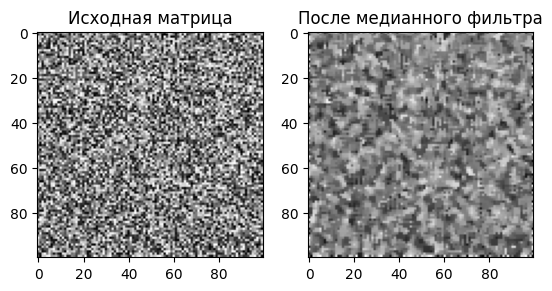

In [129]:
f, axarr = plt.subplots(1,2)
axarr[0].imshow(sample_matrix, cmap='gray')
axarr[0].set_title('Исходная матрица')

axarr[1].imshow(sample_matrix_median, cmap='gray')
axarr[1].set_title('После медианного фильтра')

Медианный фильтр применен. Попробуем на изображении. Поскольку входное изображение имеет цвета, его можно представить как матрицу, где кол-во строк = высота изображения, кол-во столбцов = ширина, и каждый пиксель является одномерным массивом из трех элементов = интенсивность red, green, blue соотвественно. Получается 3-х ранговый тензор. Поскольку мы применяем фильтр сейчас к двумерному массиву, нам нужно преобразовать изображение в карту интенсивностей. То есть, мы потеряем цвет, но получим карту интенсивностей изображения в градациях серого. Самый простой способ - взять сумму всех интенсивностей по каналам и разделить на количество каналов.
<p>
Попробуем:

Изначальное изображение

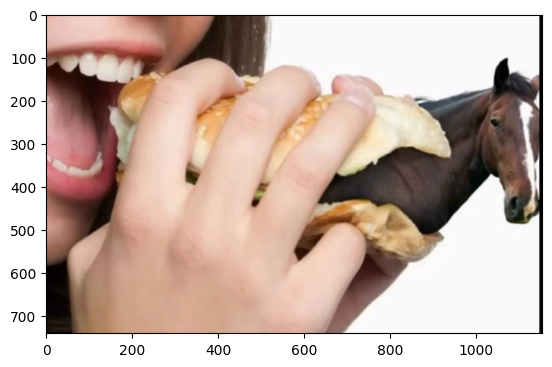

In [130]:
plt.imshow(image1_RGB)

(741, 1153, 3)


/tmp/ipykernel_5207/4285366573.py:6: RuntimeWarning: overflow encountered in scalar add
  image1_RGB_intensity[rows][columns] = sum(image1_RGB[rows][columns]) // 3


[[18 18 18 ...  2  1  0]
 [18 18 19 ...  2  1  0]
 [19 19 19 ...  2  1  0]
 ...
 [ 9  9  8 ...  3  1  0]
 [ 6  6  6 ...  3  1  0]
 [ 6  6  6 ...  3  1  0]]


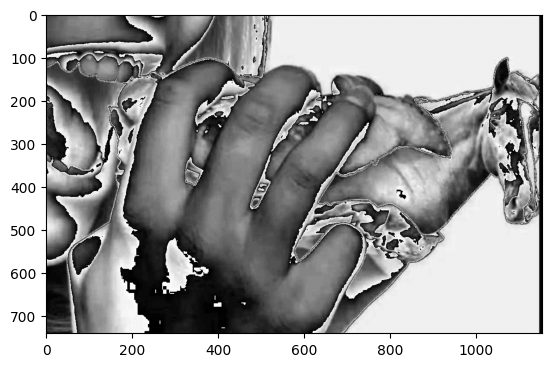

In [131]:
height, width, _ = image1_RGB.shape
image1_RGB_intensity = np.zeros((height, width), dtype='uint8')
print(image1_RGB.shape)
for rows in range(image1_RGB.shape[0]):
    for columns in range(image1_RGB.shape[1]):
        image1_RGB_intensity[rows][columns] = sum(image1_RGB[rows][columns]) // 3
plt.imshow(image1_RGB_intensity, cmap='gray')
print(image1_RGB_intensity)

Теперь соберем это все в медианный фильтр для двумерного массива:

[[18 18 18 ...  2  1  0]
 [18 18 19 ...  2  1  0]
 [19 19 19 ...  2  1  0]
 ...
 [ 9  9  8 ...  3  1  0]
 [ 6  6  6 ...  3  1  0]
 [ 6  6  6 ...  3  1  0]]


Text(0.5, 1.0, 'После медианного фильтра')

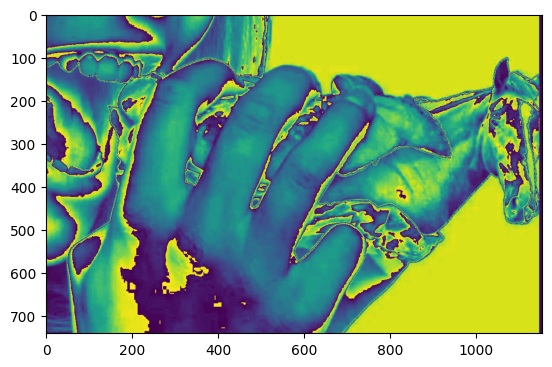

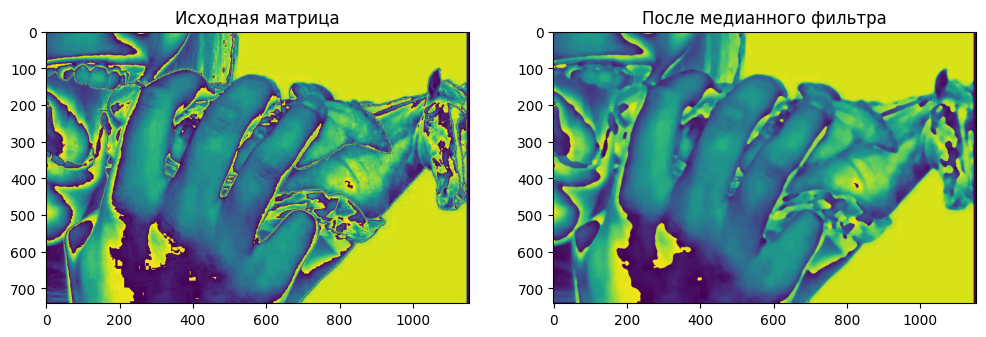

In [144]:
def median_2d(image, minor_size = 3):
    if minor_size % 2 == 0:
        print("Выбрана четная размерность апертуры")
        return image
    else:
        image_median = image.copy()
        for rows in range (image.shape[0] - minor_size + 1):
            for columns in range(image.shape[1] - minor_size + 1):
                current_minor = image[rows:rows+minor_size, columns:columns+minor_size]
                #print(current_minor)
        
                current_minor = np.reshape(current_minor, (1,current_minor.shape[0]**2))
                current_minor = np.sort(current_minor)
                #print(current_minor)
        
                median_value = int(np.median(current_minor))
                #print(median_value)
        
                image_median[rows + minor_size//2][columns + minor_size//2] = median_value
        
        return image_median

print(image1_RGB_intensity)
image = image1_RGB_intensity

plt.imshow(image)
image_median = median_2d(image)

# plt.imshow(image)
# plt.imshow(image_median)

#plt.figure(figsize=(40,40))
f, axarr = plt.subplots(1,2, figsize = (12,6))
axarr[0].imshow(image)
axarr[0].set_title('Исходная матрица')

axarr[1].imshow(median_2d(image, 13))
axarr[1].set_title('После медианного фильтра')
    

### 1.2 Фильтр гаусса

# 2. Морфологические операции

### 2.1 Эрозия

### 2.2 Дилатация

# 3. Прочие операции

### 3.1 пороговая бинаризация (для rgb и grayscale изображения)

### 3.2 выравнивание гистограммы

### 3.3 поворот изображений на угол кратный 90 градусов

# Вывод